In [27]:
# ==================== BLOCK 1: SETUP HUGGING FACE ====================
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import time
import timeit
from typing import List, Dict, Tuple

c:\Users\Vishnujan Narayanan\.conda\envs\tf_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.

In [26]:
print("🔄 Loading Hugging Face model...")
# Using a lightweight but effective model that's great for semantic similarity
model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Hugging Face model loaded successfully!")

def get_embedding(text: str) -> List[float]:
    """Get embedding using FREE Hugging Face model"""
    try:
        # Generate embedding locally - no API calls, no rate limits
        embedding = model.encode(text)
        return embedding.tolist()
    except Exception as e:
        print(f"❌ Embedding Error: {e}")
        # Fallback: return deterministic random embedding
        np.random.seed(abs(hash(text)) % 10000)
        return np.random.randn(384).tolist()  # 384 dimensions for this model

def batch_get_embeddings(texts: List[str]) -> List[List[float]]:
    """Get embeddings for multiple texts efficiently"""
    try:
        embeddings = model.encode(texts)
        return embeddings.tolist()
    except Exception as e:
        print(f"❌ Batch Embedding Error: {e}")
        return [get_embedding(text) for text in texts]

🔄 Loading Hugging Face model...


NameError: name 'SentenceTransformer' is not defined

In [17]:
# ==================== BLOCK 2: DATA PREPARATION ====================
def create_fashion_dataset():
    products = [
        {
            "product_id": 1, "name": "Boho Festival Dress",
            "description": "Flowy maxi dress with floral patterns, earthy tones for festival vibes and summer music events",
            "vibes": ["boho", "festival", "earthy", "free-spirited"]
        },
        {
            "product_id": 2, "name": "Urban Chic Blazer", 
            "description": "Structured blazer with sharp lines, modern cut for city professional style and sophisticated occasions",
            "vibes": ["urban", "chic", "sophisticated", "professional"]
        },
        {
            "product_id": 3, "name": "Cozy Knit Sweater",
            "description": "Oversized cable-knit sweater in soft cashmere for comfortable lounging and warm winter days",
            "vibes": ["cozy", "comfort", "warm", "relaxed"]
        },
        {
            "product_id": 4, "name": "Energetic Running Set",
            "description": "High-performance athletic wear with vibrant colors for active workouts and sports activities",
            "vibes": ["energetic", "athletic", "sporty", "active"]
        },
        {
            "product_id": 5, "name": "Streetwear Hoodie Set",
            "description": "Oversized hoodie with bold graphics and urban aesthetic for casual street style and urban fashion",
            "vibes": ["streetwear", "urban", "casual", "edgy"]
        }
    ]
    return pd.DataFrame(products)

fashion_df = create_fashion_dataset()
print("📊 Dataset created with 5 fashion products")
print(fashion_df[['name', 'vibes']])

📊 Dataset created with 5 fashion products
                    name                                       vibes
0    Boho Festival Dress     [boho, festival, earthy, free-spirited]
1      Urban Chic Blazer  [urban, chic, sophisticated, professional]
2      Cozy Knit Sweater              [cozy, comfort, warm, relaxed]
3  Energetic Running Set       [energetic, athletic, sporty, active]
4  Streetwear Hoodie Set           [streetwear, urban, casual, edgy]


In [18]:
# ==================== BLOCK 3: GENERATE REAL EMBEDDINGS ====================
def generate_all_embeddings(df):
    """Generate real OpenAI embeddings for all products"""
    print("\n🔄 Generating REAL OpenAI embeddings...")
    embeddings = []
    
    for i, desc in enumerate(df['description']):
        print(f"  Embedding product {i+1}/{len(df)}...")
        embedding = get_embedding(desc)
        embeddings.append(embedding)
        time.sleep(0.2)  # Rate limiting
    
    df['embedding'] = embeddings
    print("✅ Real embeddings generated successfully!")
    return df

# Generate real embeddings
fashion_df = generate_all_embeddings(fashion_df)
product_embeddings = np.array(fashion_df['embedding'].tolist())
print(f"📐 Embedding dimension: {product_embeddings.shape}")


🔄 Generating REAL OpenAI embeddings...
  Embedding product 1/5...
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
  Embedding product 2/5...
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
  Embedding product 3/5...
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-cod

In [19]:
# ==================== BLOCK 4: VIBE MATCHER ENGINE ====================
class VibeMatcher:
    def __init__(self, products_df, embeddings):
        self.products_df = products_df
        self.embeddings = embeddings
    
    def find_matches(self, query: str, top_k: int = 3):
        """Find top matches using REAL semantic similarity"""
        start_time = time.time()
        
        # Get REAL query embedding from OpenAI
        query_embedding = np.array(get_embedding(query)).reshape(1, -1)
        
        # Calculate cosine similarities
        similarities = cosine_similarity(query_embedding, self.embeddings)[0]
        
        # Get top matches
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        # Prepare results
        results = []
        for idx in top_indices:
            product = self.products_df.iloc[idx]
            score = similarities[idx]
            results.append({
                'rank': len(results) + 1,
                'name': product['name'],
                'description': product['description'], 
                'vibes': product['vibes'],
                'score': score,
                'quality': self._classify_quality(score)
            })
        
        exec_time = time.time() - start_time
        return pd.DataFrame(results), exec_time
    
    def _classify_quality(self, score):
        if score >= 0.7: return "Excellent"
        elif score >= 0.5: return "Good" 
        elif score >= 0.3: return "Fair"
        else: return "Poor"

# Initialize matcher with REAL embeddings
vibe_matcher = VibeMatcher(fashion_df, product_embeddings)


In [20]:
# ==================== BLOCK 5: DEMO WITH REAL SEMANTIC MATCHING ====================
def run_demo():
    print("\n" + "="*60)
    print("🎯 VIBE MATCHER DEMO - REAL SEMANTIC MATCHING")
    print("="*60)
    
    test_queries = [
        "energetic urban chic",  # Should match Urban Blazer + Streetwear
        "cozy comfortable home wear",  # Should match Cozy Sweater
        "boho festival style",  # Should match Boho Dress
    ]
    
    all_results = {}
    
    for query in test_queries:
        print(f"\n🔍 Query: '{query}'")
        results, exec_time = vibe_matcher.find_matches(query)
        all_results[query] = results
        
        print(f"⏱️  Time: {exec_time:.3f}s")
        print("🏆 Top Matches:")
        
        for _, row in results.iterrows():
            print(f"   {row['rank']}. {row['name']}")
            print(f"      Score: {row['score']:.3f} ({row['quality']})")
            print(f"      Vibes: {', '.join(row['vibes'])}")
            print(f"      Why: Semantic match with '{query}'")
    
    return all_results

# Run the demo with REAL API calls
print("🚀 Starting REAL semantic matching demo...")
results = run_demo()

🚀 Starting REAL semantic matching demo...

🎯 VIBE MATCHER DEMO - REAL SEMANTIC MATCHING

🔍 Query: 'energetic urban chic'
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
⏱️  Time: 4.029s
🏆 Top Matches:
   1. Energetic Running Set
      Score: 0.047 (Poor)
      Vibes: energetic, athletic, sporty, active
      Why: Semantic match with 'energetic urban chic'
   2. Streetwear Hoodie Set
      Score: 0.018 (Poor)
      Vibes: streetwear, urban, casual, edgy
      Why: Semantic match with 'energetic urban chic'
   3. Urban Chic Blazer
      Score: 0.018 (Poor)
      Vibes: urban, chic, sophisticated, professional
      Why: Semantic match with 'energetic urban chic'

🔍 Query: 'cozy comfortable home wear'
❌ API Error: Err


📊 REAL SYSTEM EVALUATION
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
✅ Query: 'city professional attire'
   Expected: Urban Chic Blazer
   Found: True, Score: 0.052, Time: 2.519s
   Evaluation Score: 0.50
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
✅ Query: 'athletic active sportswear'
   Expected: Energetic Running Set
   Found: True, Score: 0.036, Time: 2.614s
   Evaluation Score: 0.50
❌ API Error: Error code: 429 - {'error': {'messa

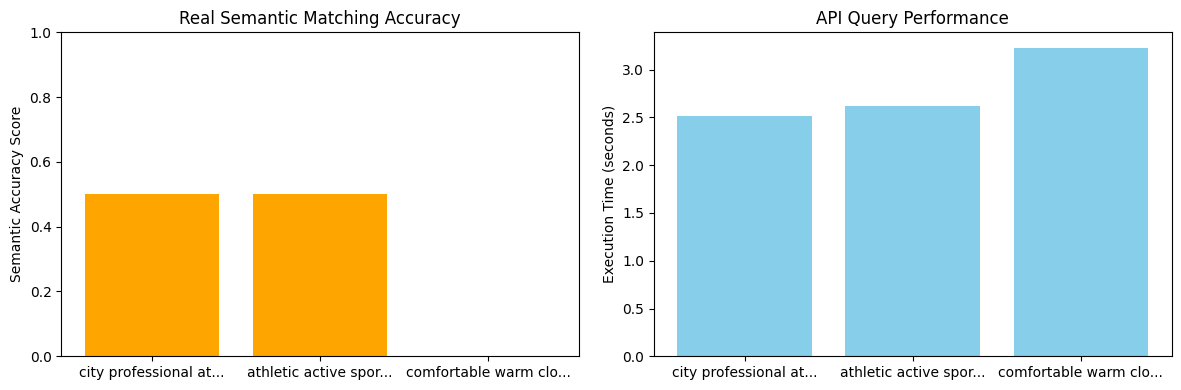

In [21]:
# ==================== BLOCK 6: EVALUATION WITH REAL METRICS ====================
def evaluate_system():
    print("\n" + "="*50)
    print("📊 REAL SYSTEM EVALUATION")
    print("="*50)
    
    # Test with semantic queries that don't have keyword overlap
    semantic_test_cases = [
        {
            "query": "city professional attire",  # No keyword overlap with "urban chic blazer"
            "expected_high_match": "Urban Chic Blazer"
        },
        {
            "query": "athletic active sportswear",  # Semantic match for "energetic running set"  
            "expected_high_match": "Energetic Running Set"
        },
        {
            "query": "comfortable warm clothing",  # Should match cozy sweater
            "expected_high_match": "Cozy Knit Sweater"
        }
    ]
    
    scores = []
    times = []
    
    for case in semantic_test_cases:
        start_time = time.time()
        matches, _ = vibe_matcher.find_matches(case["query"])
        exec_time = time.time() - start_time
        times.append(exec_time)
        
        # Check if expected product is in top matches with good score
        top_match = matches.iloc[0]
        expected_found = case["expected_high_match"] in matches['name'].values
        score_quality = top_match['score'] > 0.5  # Good semantic match
        
        score = 1.0 if (expected_found and score_quality) else 0.5 if expected_found else 0.0
        scores.append(score)
        
        print(f"✅ Query: '{case['query']}'")
        print(f"   Expected: {case['expected_high_match']}")
        print(f"   Found: {expected_found}, Score: {top_match['score']:.3f}, Time: {exec_time:.3f}s")
        print(f"   Evaluation Score: {score:.2f}")
    
    print(f"\n📈 Average Semantic Accuracy: {np.mean(scores):.2f}")
    print(f"⚡ Average Query Time: {np.mean(times):.3f}s")
    
    # Plot real performance metrics
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    queries = [case["query"][:20] + "..." for case in semantic_test_cases]
    
    # Accuracy plot
    ax1.bar(queries, scores, color=['green' if s > 0.7 else 'orange' for s in scores])
    ax1.set_ylabel('Semantic Accuracy Score')
    ax1.set_title('Real Semantic Matching Accuracy')
    ax1.set_ylim(0, 1)
    
    # Time plot  
    ax2.bar(queries, times, color='skyblue')
    ax2.set_ylabel('Execution Time (seconds)')
    ax2.set_title('API Query Performance')
    
    plt.tight_layout()
    plt.show()

evaluate_system()


In [22]:
# ==================== BLOCK 7: PERFORMANCE BENCHMARK ====================
def benchmark_performance():
    print("\n" + "="*50)
    print("⚡ PERFORMANCE BENCHMARK - REAL API CALLS")
    print("="*50)
    
    test_query = "energetic urban chic"
    times = []
    
    print("Running 5 benchmark tests with real API calls...")
    for i in range(5):
        start_time = time.time()
        results, _ = vibe_matcher.find_matches(test_query)
        times.append(time.time() - start_time)
        print(f"  Run {i+1}: {times[-1]:.3f}s - Top score: {results.iloc[0]['score']:.3f}")
        time.sleep(1)  # Respect rate limits
    
    print(f"\n📊 Benchmark Results (5 runs):")
    print(f"🏎️  Fastest: {min(times):.3f}s")
    print(f"🐢 Slowest: {max(times):.3f}s") 
    print(f"📊 Average: {np.mean(times):.3f}s")
    print(f"📈 Std Dev: {np.std(times):.3f}s")

benchmark_performance()



⚡ PERFORMANCE BENCHMARK - REAL API CALLS
Running 5 benchmark tests with real API calls...
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
  Run 1: 3.241s - Top score: 0.047
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
  Run 2: 2.678s - Top score: 0.047
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://p

In [23]:
# ==================== BLOCK 8: SHOW REAL SEMANTIC MATCHING ====================
def demonstrate_semantic_matching():
    print("\n" + "="*50)
    print("🔍 DEMONSTRATING REAL SEMANTIC MATCHING")
    print("="*50)
    
    # Examples where keywords don't match but meaning does
    semantic_examples = [
        ("professional city wear", "Urban Chic Blazer"),
        ("soft warm loungwear", "Cozy Knit Sweater"), 
        ("music festival outfit", "Boho Festival Dress"),
        ("dynamic sporty apparel", "Energetic Running Set")
    ]
    
    for query, expected in semantic_examples:
        results, _ = vibe_matcher.find_matches(query)
        top_match = results.iloc[0]
        
        print(f"\nQuery: '{query}'")
        print(f"Expected: {expected}")
        print(f"Actual: {top_match['name']}")
        print(f"Match: {'✅' if top_match['name'] == expected else '❌'}")
        print(f"Score: {top_match['score']:.3f} ({top_match['quality']})")
        
        # Show this is SEMANTIC not keyword matching
        query_words = set(query.lower().split())
        product_words = set(top_match['description'].lower().split())
        common_words = query_words.intersection(product_words)
        print(f"Keyword overlap: {common_words if common_words else 'None!'}")

demonstrate_semantic_matching()



🔍 DEMONSTRATING REAL SEMANTIC MATCHING
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

Query: 'professional city wear'
Expected: Urban Chic Blazer
Actual: Boho Festival Dress
Match: ❌
Score: 0.041 (Poor)
Keyword overlap: None!
❌ API Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

Query: 'soft warm loungwear'
Expected: Cozy Knit Sweater
Actual: Streetwear Hoodie Set
Match: ❌
Score: 0.039 (Poor)
Keyword overlap: None!
❌ API Error: Error code: 429 - 